**PRICES DATA PREPARATION**

In [ ]:
import pandas as pd

abnb = pd.read_excel("Airbnb-prices.xlsx")
f = pd.read_excel("Ford-prices.xlsx")
intc = pd.read_excel("Intel-prices.xlsx")
sp500 = pd.read_excel("S&P500-prices.xlsx")
tsla = pd.read_excel("Tesla-prices.xlsx")
zm = pd.read_excel("Zoom-prices.xlsx")

^Load prices files and import pandas

In [ ]:
abnb.head()

,Date,Price,CVol,Change,% Change,% Return,Total Return (Gross),Cumulative Return %,Open,High,Low,Cumulative Change %
0,2026-04-13,130.32,3249792.0,1.36,1.054591,1.054591,130.32,-26.765945,127.20,130.650,125.360,-26.765945
1,2026-04-10,128.96,3572699.0,-0.20,-0.154847,-0.154847,128.96,-27.530205,128.87,130.535,124.835,-27.530205
2,2026-04-09,129.16,3653657.0,-2.24,-1.704718,-1.704718,129.16,-27.417814,130.45,130.960,126.800,-27.417814
3,2026-04-08,131.40,3797224.0,6.43,5.145235,5.145235,131.40,-26.159033,130.99,134.260,130.490,-26.159033
4,2026-04-07,124.97,2735296.0,-1.84,-1.450990,-1.450990,124.97,-29.772408,126.40,126.820,123.410,-29.772408


^ Double check column names for data prep

In [ ]:
def clean(df, name):
    df = df[['Date', 'Price']]
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date')
    df = df.set_index('Date')
    df = df.rename(columns={'Price': name})
    return df

^ select date and price columns, sort dates chronologically, rename the price column for each asset

In [ ]:
abnb = clean(abnb, 'ABNB')
f = clean(f, 'F')
intc = clean(intc, 'INTC')
sp500 = clean(sp500, 'SP500')
tsla = clean(tsla, 'TSLA')
zm = clean(zm, 'ZM')

/tmp/ipykernel_959/1627300385.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Date'] = pd.to_datetime(df['Date'])
/tmp/ipykernel_959/1627300385.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Date'] = pd.to_datetime(df['Date'])
/tmp/ipykernel_959/1627300385.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/

^ Clean each dataset, standardized date formatting and structure across all stocks; renamed price columns to match each company ticker; prepared all datasets for merge and analysis

^

In [ ]:
df = abnb.join([tsla, f, zm, intc, sp500], how='inner')

^Merged all cleaned datasets innto one df; aligned all stocks by common dates using inner join; combined stock prices and benchmark prices into signle dataset

In [ ]:
df.head()

,ABNB,TSLA,F,ZM,INTC,SP500
Date,,,,,,
2021-04-13,177.95,254.10640,12.20,342.75,65.22,4141.593759
2021-04-14,176.43,244.07640,12.24,329.20,64.19,4124.660630
2021-04-15,175.35,246.28307,12.24,332.38,65.02,4170.422790
2021-04-16,178.69,246.59308,12.23,329.95,64.75,4185.468711
2021-04-19,174.58,238.20975,12.11,324.33,63.63,4163.258095


^Check merged dataset to make sure its set up correctly

In [ ]:
df.to_csv("combined_prices.csv")

In [ ]:
from google.colab import files
files.download("combined_prices.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

^Save cleaned dataset as 'combined_prices.csv'

**RETURNS DATA PREPARATION**

In [ ]:
abnb = pd.read_excel("Airbnb-returns.xlsx")
tsla = pd.read_excel("Tesla-returns.xlsx")
f = pd.read_excel("Ford-returns.xlsx")
zm = pd.read_excel("Zoom-returns.xlsx")
intc = pd.read_excel("Intel-returns.xlsx")
sp500 = pd.read_excel("S&P500-returns.xlsx")

^Load returns files

In [ ]:
print(abnb.head())
print(abnb.columns)
print(tsla.head())
print(tsla.columns)
print(f.head())
print(f.columns)
print(zm.head())
print(zm.columns)
print(intc.head())
print(intc.columns)
print(sp500.head())
print(sp500.columns)

        Date  % Return
0 2026-04-15  3.033246
1 2026-04-14  2.708717
2 2026-04-13  1.054591
3 2026-04-10 -0.154847
4 2026-04-09 -1.704718
Index(['Date', '% Return'], dtype='object')
        Date  % Return
0 2026-04-15  7.073064
1 2026-04-14  3.342603
2 2026-04-13  0.994412
3 2026-04-10  0.963486
4 2026-04-09  0.690459
Index(['Date', '% Return'], dtype='object')
        Date  % Return
0 2026-04-15  0.118020
1 2026-04-14  4.523033
2 2026-04-13  0.247314
3 2026-04-10 -0.898696
4 2026-04-09  0.492616
Index(['Date', '% Return'], dtype='object')
        Date  % Return
0 2026-04-15  7.536408
1 2026-04-14 -0.483092
2 2026-04-13  4.492680
3 2026-04-10 -5.700345
4 2026-04-09  0.961192
Index(['Date', '% Return'], dtype='object')
        Date  % Return
0 2026-04-15  0.948122
1 2026-04-14 -2.101865
2 2026-04-13  4.488623
3 2026-04-10  1.069342
4 2026-04-09  4.698893
Index(['Date', '% Return'], dtype='object')
        Date  % Return
0 2026-04-14  1.180153
1 2026-04-13  1.017330
2 2026-04-10 -0.10680

^Check column headings

In [ ]:
def clean_returns(df, name):
    df = df[['Date', '% Return']].copy()

    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date')
    df = df.set_index('Date')

    df['% Return'] = df['% Return'] / 100

    df = df.rename(columns={'% Return': name})

    return df

selects date and % return columns from the dataset; converts dates to correct datetime format; sorts data chronologically and sets date as the index; converts % return todecimal form

In [ ]:
abnb = clean_returns(abnb, 'ABNB')
tsla = clean_returns(tsla, 'TSLA')
f = clean_returns(f, 'F')
zm = clean_returns(zm, 'ZM')
intc = clean_returns(intc, 'INTC')
sp500 = clean_returns(sp500, 'SP500')

^Applied cleaning function to each dataset to extract and standardize reurns data; converts % to decimals; formats date correctly; renames columns

In [ ]:
returns = abnb.join([tsla, f, zm, intc, sp500], how='inner')

^Merges all stocks and market return datasets into single dataframe; aligns data on common dates using inner join; creates unified dataset for further analysis

**CREATE MONTHLY RETURNS**

In [ ]:
monthly_returns = returns.resample('ME').apply(lambda x: (1 + x).prod() - 1)

^Resamples daily rturns into monthly freuqnecy using end of month dates; compounds daily returns within eaach month to calculate true monthly rturns; converts high frequency data into a format suitable for financial analysis; prepares returns for CAPM and Farma French

In [ ]:
monthly_returns.head()

,ABNB,TSLA,F,ZM,INTC,SP500
Date,,,,,,
2021-04-30,-0.015056,-0.039805,-0.057190,-0.038540,-0.115195,0.002786
2021-05-31,-0.187077,-0.118714,0.259099,0.037425,-0.001094,0.006534
2021-06-30,0.090741,0.087138,0.022712,0.167406,-0.017157,0.023005
2021-07-31,-0.059619,0.011034,-0.061238,-0.023073,-0.043106,0.023453
2021-08-31,0.076245,0.070605,-0.065950,-0.234330,0.012818,0.029981


^Ensure dataset is correct

In [ ]:
monthly_returns.to_csv("monthly_returns.csv")

^Save monthly return dataset

**FARMA FRENCH/RISK FREE RATE**

In [ ]:
ff = pd.read_csv("F-F_Monthly_Research_Data_Factors.csv")
ff.head()

,Date,Mkt-RF,SMB,HML,RF
0,192607,2.89,-2.55,-2.39,0.22
1,192608,2.64,-1.14,3.81,0.25
2,192609,0.38,-1.36,0.05,0.23
3,192610,-3.27,-0.14,0.82,0.32
4,192611,2.54,-0.11,-0.61,0.31


Loads Fama French data and see first few rows

In [ ]:
ff['Date'] = pd.to_datetime(ff['Date'], format='%Y%m', errors='coerce')

^Converts date column from numeric format to datetime format

In [ ]:
ff = ff.dropna()

^Drops any non-data rows

In [ ]:
ff = ff.set_index('Date')

^Sets date column as index for merging/time series

In [ ]:
columns_to_convert = ['Mkt-RF', 'SMB', 'HML', 'RF']
ff[columns_to_convert] = ff[columns_to_convert].apply(pd.to_numeric)

^Ensures all columns are numeric

In [ ]:
ff = ff / 100

^Converts values from % to decimal

In [ ]:
ff.index = ff.index + pd.offsets.MonthEnd(0)

^Adjusts dates to month end to align with monthly return data

In [ ]:
final = monthly_returns.merge(ff, left_index=True, right_index=True)

^Merges monthly stock return data with Fama French factors and the risk free rate; aligns both datasets based on matching monthly dates; creates unified dataset for finanical analysis

In [ ]:
for col in ['ABNB','TSLA','F','ZM','INTC']:
    final[col + '_excess'] = final[col] - final['RF']

^Calculates excess returns by subtracting the risk free rate from each stocks return

In [ ]:
final.head()

,ABNB,TSLA,F,ZM,INTC,SP500,Mkt-RF,SMB,HML,RF,ABNB_excess,TSLA_excess,F_excess,ZM_excess,INTC_excess
Date,,,,,,,,,,,,,,,
2021-04-30,-0.015056,-0.039805,-0.057190,-0.038540,-0.115195,0.002786,0.0495,-0.0319,-0.0102,0.0,-0.015056,-0.039805,-0.057190,-0.038540,-0.115195
2021-05-31,-0.187077,-0.118714,0.259099,0.037425,-0.001094,0.006534,0.0030,-0.0020,0.0704,0.0,-0.187077,-0.118714,0.259099,0.037425,-0.001094
2021-06-30,0.090741,0.087138,0.022712,0.167406,-0.017157,0.023005,0.0274,0.0170,-0.0786,0.0,0.090741,0.087138,0.022712,0.167406,-0.017157
2021-07-31,-0.059619,0.011034,-0.061238,-0.023073,-0.043106,0.023453,0.0134,-0.0393,-0.0179,0.0,-0.059619,0.011034,-0.061238,-0.023073,-0.043106
2021-08-31,0.076245,0.070605,-0.065950,-0.234330,0.012818,0.029981,0.0294,-0.0032,-0.0023,0.0,0.076245,0.070605,-0.065950,-0.234330,0.012818


^Ensure everything is merged correctly and there are no errors in the data

In [ ]:
final.to_csv("returns_factors_final.csv")

In [ ]:
from google.colab import files
files.download("returns_factors_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

^Save and download file

**PRICE vs RETURNS BEHAVIOR**

<Axes: title={'center': 'Price Behavior Over Time'}, xlabel='Date'>

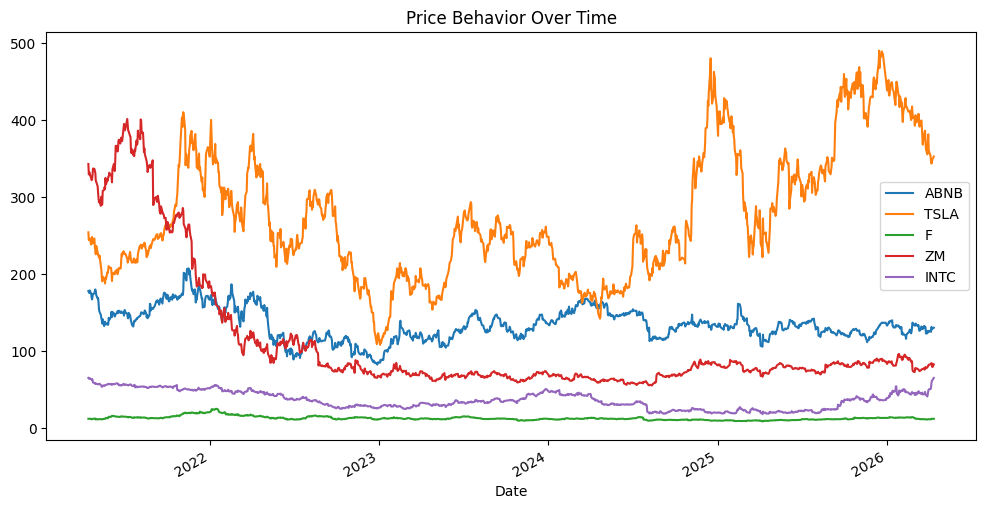

In [ ]:
df[['ABNB','TSLA','F','ZM','INTC']].plot(figsize=(12,6), title='Price Behavior Over Time')

<Axes: title={'center': 'Price Behavior Over Time'}, xlabel='Date'>

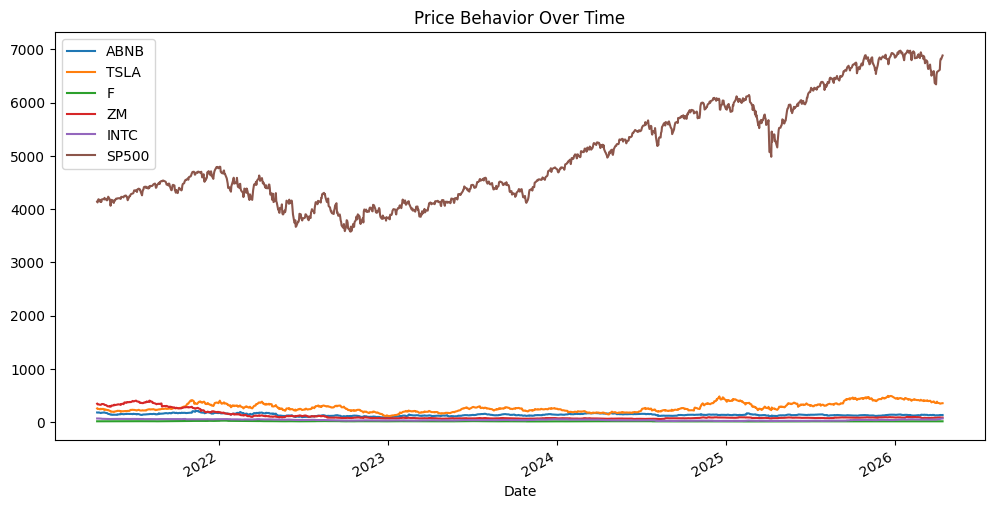

In [ ]:
df[['ABNB','TSLA','F','ZM','INTC','SP500']].plot(figsize=(12,6), title='Price Behavior Over Time')

^Plots daily returns for all selected stocks; shows why returns are more appropriate for financial analysis

<Axes: title={'center': 'Monthly Return Behavior'}, xlabel='Date'>

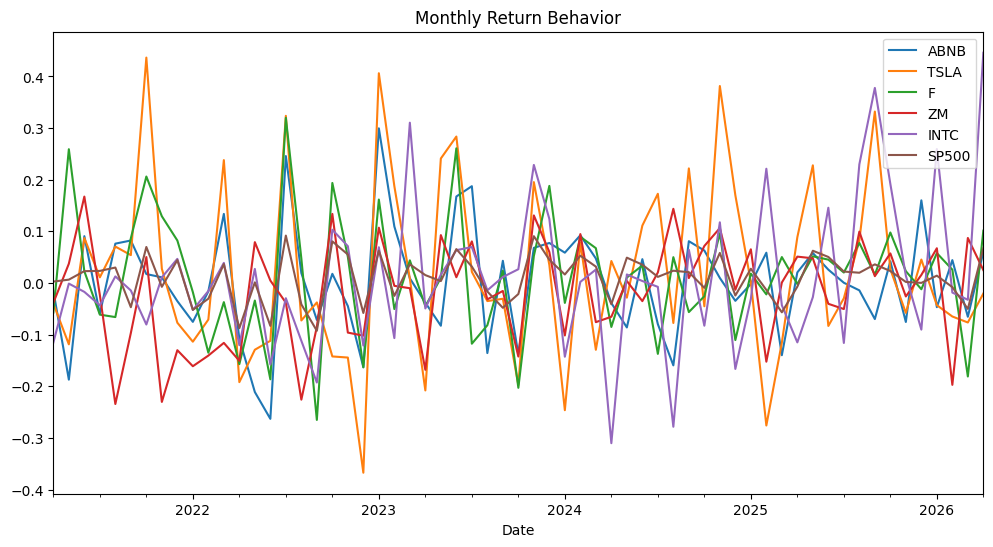

In [ ]:
monthly_returns[['ABNB','TSLA','F','ZM','INTC','SP500']].plot(figsize=(12,6), title='Monthly Return Behavior')

^Plots monthly returns for all assets; shows how returns fluctuate around a more stable mean than price overtime; highlights differences in volatility and return patterns across assets

**SUMMARY STATISTICS**

In [ ]:
monthly_returns[['ABNB','TSLA','F','ZM','INTC','SP500']].describe()

,ABNB,TSLA,F,ZM,INTC,SP500
count,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000
mean,0.001154,0.020186,0.011877,-0.017393,0.010586,0.010243
std,0.106057,0.170654,0.116077,0.100261,0.140975,0.043959
min,-0.263010,-0.367334,-0.265092,-0.234330,-0.310165,-0.092488
25%,-0.069792,-0.077390,-0.056300,-0.095997,-0.080330,-0.016460
50%,0.009793,-0.020309,0.020276,-0.005467,-0.001094,0.016531
75%,0.059946,0.088748,0.067524,0.060150,0.064428,0.036723
max,0.299532,0.436530,0.319856,0.167406,0.445955,0.091877


^Shows descriptive stats for monthly returns; summarizes mean return, volatility, and extreme values; helps compare performance and risk across assets

**ROLLING VOLATILITY**

In [ ]:
rolling_vol = monthly_returns[['ABNB','TSLA','F','ZM','INTC','SP500']].rolling(window=3).std()
rolling_vol.head()

,ABNB,TSLA,F,ZM,INTC,SP500
Date,,,,,,
2021-04-30,NaN,NaN,NaN,NaN,NaN,NaN
2021-05-31,NaN,NaN,NaN,NaN,NaN,NaN
2021-06-30,0.140218,0.103855,0.164470,0.104147,0.061764,0.010756
2021-07-31,0.139066,0.104084,0.166104,0.097329,0.021199,0.009641
2021-08-31,0.082943,0.040029,0.049884,0.200957,0.027986,0.003904


^Calculates rolling volatility using a 3-month window; uses std deviation of returns as a meausre of risk; captures how volatility changes over time instead of assuming its constant

<Axes: title={'center': '3-Month Rolling Volatility'}, xlabel='Date'>

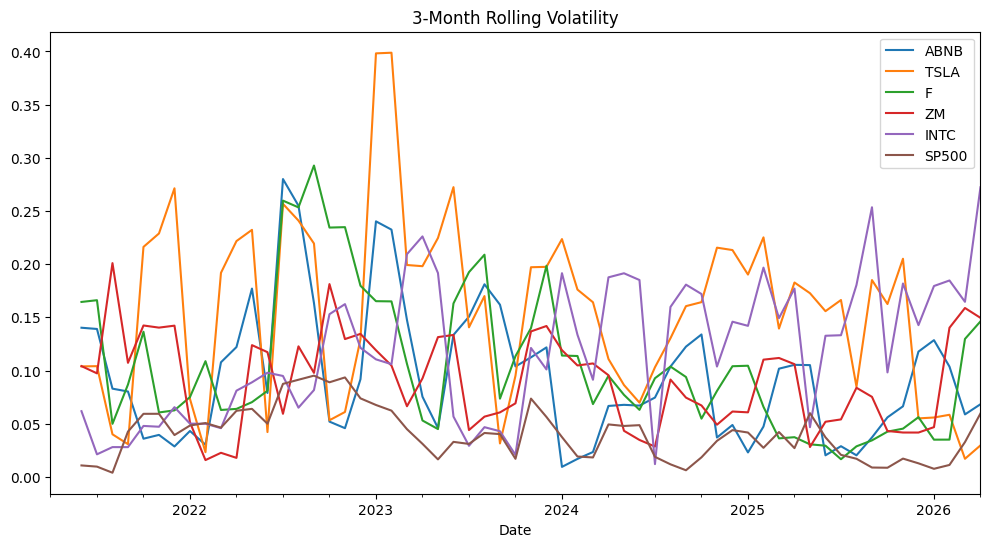

In [ ]:
rolling_vol.plot(figsize=(12,6), title='3-Month Rolling Volatility')

^Plots time varying volatility for all assets; shows how risk changes over time; highlights periods of higher and lower volatility

**VOLATILITY CLUSTERING**

<Axes: title={'center': 'Absolute Monthly Returns'}, xlabel='Date', ylabel='Monthly Return %'>

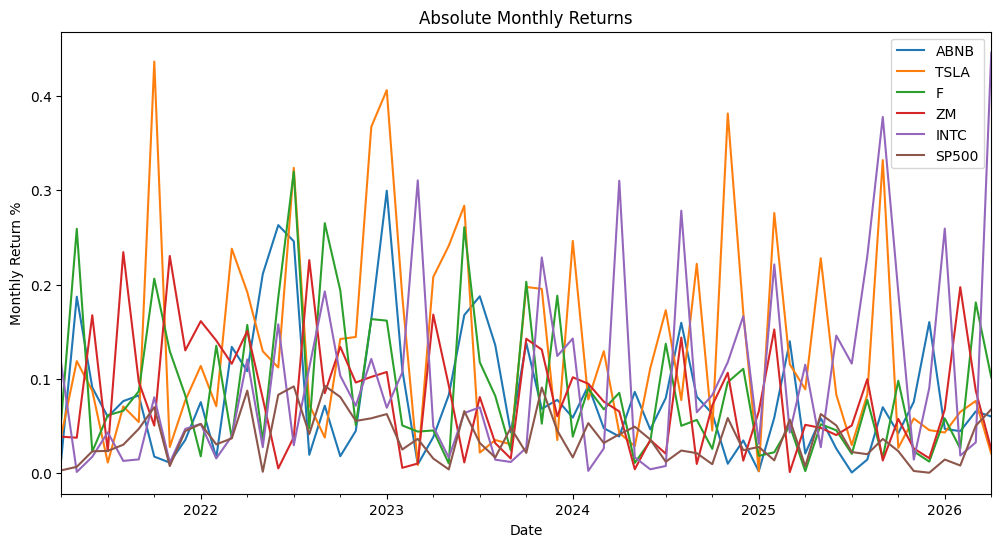

In [ ]:
abs_returns = monthly_returns[['ABNB','TSLA','F','ZM','INTC','SP500']].abs()
abs_returns.plot(figsize=(12,6), title='Absolute Monthly Returns', ylabel='Monthly Return %')

^Plots the absolute value of monthly returns to highlight volatility patterns; makes large movements easier to see; shows volatility clustering, where periods of high volatility tend to group together

**DIFFERENCES ACROSS MARKET CONDITIONS**

In [ ]:
high_vol_periods = rolling_vol.mean().sort_values(ascending=False)

high_vol_df = high_vol_periods.to_frame(name='Average Rolling Volatility')
high_vol_df

,Average Rolling Volatility
TSLA,0.155360
INTC,0.119372
F,0.105121
ABNB,0.094229
ZM,0.090583
SP500,0.040266


^Calculates the average rolling volatility for each asset; identifies which assets experience higher overall volatility; helps compare how risk differs across assets and market conditions

<Axes: title={'center': 'Average Rolling Volatility by Asset'}>

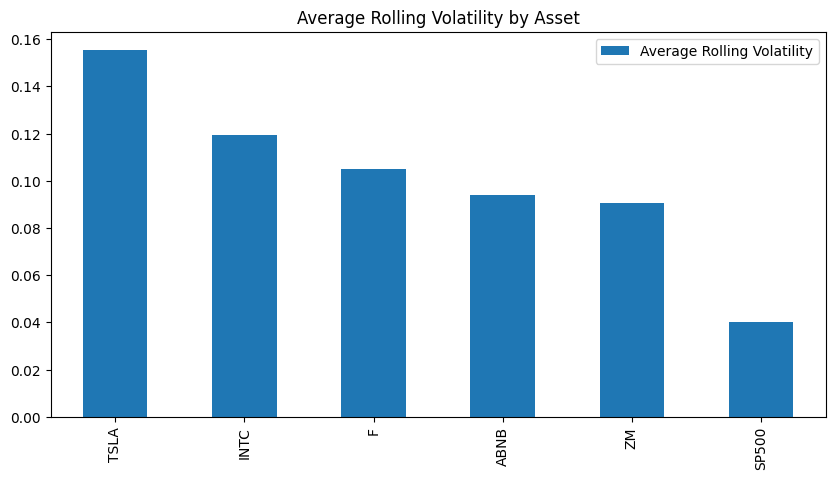

In [ ]:
high_vol_df.plot(kind='bar', figsize=(10,5), title='Average Rolling Volatility by Asset')

^Creates bar chart to compare volatility across assets; sorts assets frm lowest to highest volatility; highlights different levels in volatility

**FACTOR TILTED PORTFOLIO CONSTRUCTION**

In [ ]:
weights = {
    'ABNB': 0.25,
    'TSLA': 0.30,
    'ZM': 0.20,
    'F': 0.15,
    'INTC': 0.10
}

^Assigns higher weights to growth-oriented and more volatile stocks; reduces exposure to more stable, value-oriented comapnies; creates a portfolio tilted toward higher risk and potential return

**PORTFOLIO RETURNS & VOLATILITY**

In [ ]:
portfolio_returns = (
    monthly_returns[['ABNB','TSLA','ZM','F','INTC']]
    * pd.Series(weights)
).sum(axis=1)

portfolio_returns.head()

,0
Date,
2021-04-30,-0.043511
2021-05-31,-0.036143
2021-06-30,0.083999
2021-07-31,-0.029705
2021-08-31,-0.015234


^Calculates portfolio returns as a weighted average of individual asset returns; applies predefined weights to each asset's monthly return; produces a time series of portfolio performance for further risk/return analysis

In [ ]:
portfolio_mean = portfolio_returns.mean()
portfolio_vol = portfolio_returns.std()

portfolio_mean, portfolio_vol

(np.float64(0.0057058778325013125), 0.09178297801283943)

^Calculates the average monthly return of the portfolio; computes the portfolio's volatility using the std deviation

**CORRELATION MATRIX**

In [ ]:
corr_matrix = monthly_returns[['ABNB','TSLA','ZM','F','INTC']].corr()
corr_matrix

,ABNB,TSLA,ZM,F,INTC
ABNB,1.000000,0.505899,0.077075,0.417807,0.215540
TSLA,0.505899,1.000000,0.393010,0.380270,0.165708
ZM,0.077075,0.393010,1.000000,0.266842,0.197707
F,0.417807,0.380270,0.266842,1.000000,0.349560
INTC,0.215540,0.165708,0.197707,0.349560,1.000000


^Shows how strongly asset returns move together (closer to one, more correlated)

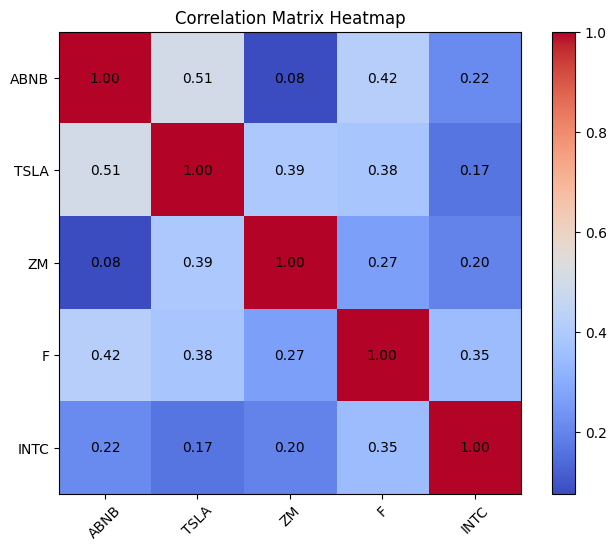

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='none')
plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

# Add values inside the cells
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                 ha='center', va='center', color='black')

plt.title('Correlation Matrix Heatmap')
plt.show()

^Visualizes the correlation matrix using a heatmap; highlights relationships between assets; helps ID diversification benefits (low correlation) and conentration risk (high correlation)

**VALUE AT RISK (VaR)/CONDITIONAL VALUE AT RISK (CVaR)**

In [ ]:
import numpy as np

# 5% VaR
VaR_95 = np.percentile(portfolio_returns, 5)

VaR_95

np.float64(-0.14209260786980527)

^Calculates the 5% VAR for the portfolio; estimates the potential loss in the worst 5% of months; provides a meausre of downside risk under normal market conditions (there is a 5% chance the portfolio loses 14% or more in a month)

In [ ]:
# CVaR (Expected Shortfall)
CVaR_95 = portfolio_returns[portfolio_returns <= VaR_95].mean()

CVaR_95

np.float64(-0.1625645955977701)

^Calculates the average loss given that the VaR threshold has been breached; provides a more informative downside risk than VaR

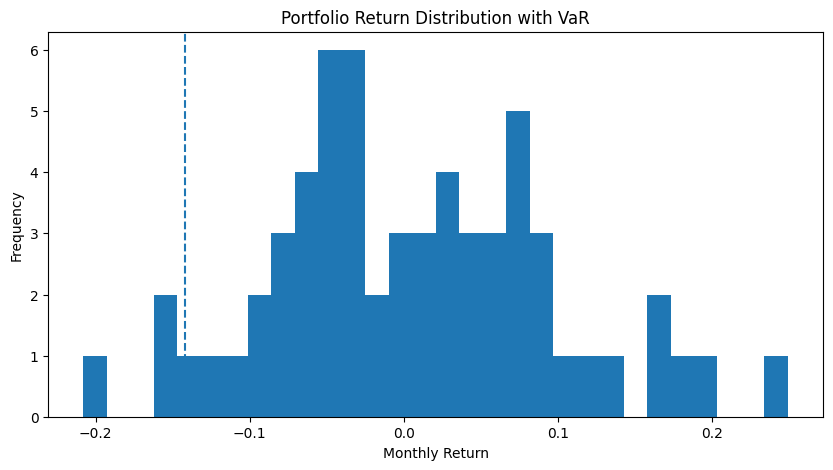

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(portfolio_returns, bins=30)

# VaR line
plt.axvline(VaR_95, linestyle='--')

plt.title('Portfolio Return Distribution with VaR')
plt.xlabel('Monthly Return')
plt.ylabel('Frequency')
plt.show()

^Plots the distribution of portfolio returns to visualize overall risk; adds a vertical line to indicate the VaR threshold; highlights the left tail of he distribution where extreme losses occur

**ASSET PRICING MODELS & FACTOR ANALYSIS**

In [ ]:
reg_data = final.copy()
reg_data['portfolio_return'] = portfolio_returns
reg_data['portfolio_excess'] = reg_data['portfolio_return'] - reg_data['RF']
reg_data = reg_data.dropna()

reg_data[['portfolio_return', 'RF', 'portfolio_excess']].describe()

,portfolio_return,RF,portfolio_excess
count,59.000000,59.000000,59.000000
mean,0.005535,0.002732,0.002803
std,0.092612,0.001724,0.092387
min,-0.207920,0.000000,-0.211220
25%,-0.056778,0.000700,-0.060628
50%,0.003303,0.003400,-0.000997
75%,0.068845,0.004000,0.065345
max,0.249360,0.004800,0.245860


^Adds portfolio return series to the final dataset; calculates portfolio excess returns by subtracting the risk free rate; prepares clean rgression datset for CAPM and factor model analysis

**CAPM**

In [ ]:
import statsmodels.api as sm

In [ ]:
# Independent variable (market excess return)
X = reg_data[['Mkt-RF']]
X = sm.add_constant(X)

# Dependent variable (portfolio excess return)
Y = reg_data['portfolio_excess']

# Run regression
capm_model = sm.OLS(Y, X).fit()

capm_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       portfolio_excess   R-squared:                       0.510
Model:                            OLS   Adj. R-squared:                  0.501
Method:                 Least Squares   F-statistic:                     59.35
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           2.14e-10
Time:                        14:25:36   Log-Likelihood:                 78.360
No. Observations:                  59   AIC:                            -152.7
Df Residuals:                      57   BIC:                            -148.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0087      0.009     -1.013      0.316      -0.026       0.009
Mkt-RF         1.4820      0.192      7.704      0.000       1.097       1.867
==============================================================================
Omnibus:                        1.203   Durbin-Watson:                   1.861
Prob(Omnibus):                  0.548   Jarque-Bera (JB):                1.011
Skew:                          -0.069   Prob(JB):                        0.603
Kurtosis:                       2.374   Cond. No.                         22.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

^Runs the CAPM regression using market excess returns as the only factor; estimates the portfolio's alpha and beta; provides model stats like r-squared and sig levels

**FAMA FRENCH 3 FACTOR MODEL**

In [ ]:
# Independent variables (3 factors)
X = reg_data[['Mkt-RF', 'SMB', 'HML']]
X = sm.add_constant(X)

# Dependent variable
Y = reg_data['portfolio_excess']

# Run regression
ff3_model = sm.OLS(Y, X).fit()

ff3_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       portfolio_excess   R-squared:                       0.624
Model:                            OLS   Adj. R-squared:                  0.603
Method:                 Least Squares   F-statistic:                     30.36
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           1.03e-11
Time:                        14:27:13   Log-Likelihood:                 86.129
No. Observations:                  59   AIC:                            -164.3
Df Residuals:                      55   BIC:                            -155.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0010      0.008      0.121      0.904      -0.015       0.017
Mkt-RF         1.2348      0.182      6.774      0.000       0.869       1.600
SMB            1.0270      0.286      3.590      0.001       0.454       1.600
HML           -0.3989      0.190     -2.101      0.040      -0.779      -0.018
==============================================================================
Omnibus:                        2.168   Durbin-Watson:                   1.985
Prob(Omnibus):                  0.338   Jarque-Bera (JB):                1.365
Skew:                          -0.020   Prob(JB):                        0.505
Kurtosis:                       2.256   Cond. No.                         38.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

^Runs Fama French 3 factor model using market, size (SMB), and value (HML) factors; estimates facor loadings to understand portfolio exposure to different risk sources; allows comparison with CAPM to evaluate improvement in explanatory power

**CAPM & FAMA FRENCH MODELS COMPARISON**

In [ ]:
print("CAPM R-squared:", capm_model.rsquared)
print("FF3 R-squared:", ff3_model.rsquared)

print("\nCAPM Alpha:", capm_model.params['const'])
print("FF3 Alpha:", ff3_model.params['const'])

CAPM R-squared: 0.5100810597206412
FF3 R-squared: 0.6235143432120286

CAPM Alpha: -0.008731923858694847
FF3 Alpha: 0.000977647641196512


^Compares explanatory power (r-squared) between CAPM and FF3; evaluates how adding size and value factors improves model fit; compares alpha estimates to determine if abnormal returns perisst after controlling for additional risk factors

**FAMA FRENCH 3 FACTOR MODELS FOR INDIVIDUAL STOCKS**

In [ ]:
stocks = ['ABNB_excess', 'TSLA_excess', 'F_excess', 'ZM_excess', 'INTC_excess']

results = {}

for stock in stocks:
    Y = reg_data[stock]

    X = reg_data[['Mkt-RF', 'SMB', 'HML']]
    X = sm.add_constant(X)

    model = sm.OLS(Y, X).fit()

    results[stock] = model.params

# Display results
import pandas as pd
results_df = pd.DataFrame(results).T
results_df

,const,Mkt-RF,SMB,HML
ABNB_excess,-0.004999,1.072779,0.588088,-0.298373
TSLA_excess,0.027596,1.385809,2.142019,-1.318767
F_excess,-0.003238,1.690150,0.212055,0.449380
ZM_excess,-0.022030,0.786527,0.967343,-0.247466
INTC_excess,-0.011598,1.400003,0.121341,0.533611


^Runs the Fama French 3 factor model seperately for each individual stock; estimates factor loadings (alpha, market, size, and value exposures); stores regression coefficients in a table for easy comparison across assets

## Final Investment Insight

- The factor-tilted portfolio exhibits high volatility and significant downside risk driven by growth-oriented assets.
- While diversification provides some benefit, correlations between growth stocks limit its effectiveness.
- CAPM and Fama-French results show that returns are driven by factor exposure rather than abnormal performance.
- The portfolio may be suitable for aggressive investors, but does not provide an optimal risk-return tradeoff for most investors.